<a href="https://colab.research.google.com/github/DhanshreeRaut/Machine-Vision--CM59/blob/main/practical_5_CM23059.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import zipfile

zip_path = "archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

In [ ]:
image_paths = glob.glob("/content/CroppedYalePNG/*.png")

print("Total Images =", len(image_paths))

Total Images = 2452


In [ ]:
face_detected = 0
eye_detected = 0

results = []

for img_path in image_paths:

    img = cv2.imread(img_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(faces) > 0:
        face_detected += 1

    eye_found = False

    for (x,y,w,h) in faces:

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        if len(eyes) > 0:
            eye_found = True

        for (ex,ey,ew,eh) in eyes:

            cv2.rectangle(
                roi_color,
                (ex,ey),
                (ex+ew,ey+eh),
                (0,255,0),
                2
            )

        cv2.rectangle(
            img,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            2
        )

    if eye_found:
        eye_detected += 1

    results.append((img_path,img))

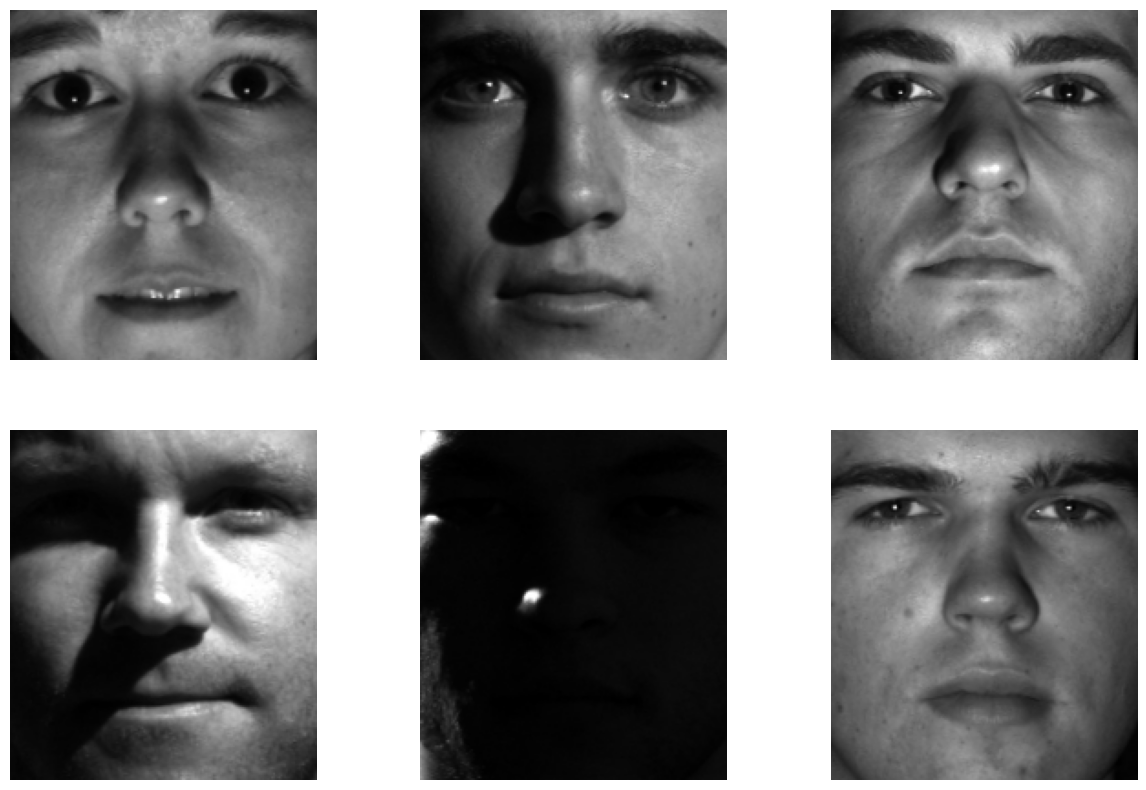

In [ ]:
plt.figure(figsize=(15,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = cv2.cvtColor(results[i][1],cv2.COLOR_BGR2RGB)

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [ ]:
total = len(image_paths)

face_accuracy = (face_detected/total)*100

eye_accuracy = (eye_detected/total)*100

print("Total Images :", total)

print("Face Detection Accuracy : {:.2f}%".format(face_accuracy))

print("Eye Detection Accuracy : {:.2f}%".format(eye_accuracy))

Total Images : 2452
Face Detection Accuracy : 5.10%
Eye Detection Accuracy : 1.59%


In [ ]:
import os
import re
import cv2

lighting = {
    "Ambient": 0,
    "Normal": 0,
    "Medium": 0,
    "Difficult": 0
}

lighting_detect = {
    "Ambient": 0,
    "Normal": 0,
    "Medium": 0,
    "Difficult": 0
}

for img_path in image_paths:

    filename = os.path.basename(img_path)

    # Ambient images
    if "Ambient" in filename:
        category = "Ambient"

    else:
        # Extract illumination angle after 'A'
        match = re.search(r'A(-?\d+)', filename)

        if match:
            angle = int(match.group(1))

            if abs(angle) <= 20:
                category = "Normal"

            elif abs(angle) <= 50:
                category = "Medium"

            else:
                category = "Difficult"
        else:
            continue

    lighting[category] += 1

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) > 0:
        lighting_detect[category] += 1

print("Detection Accuracy:\n")

for key in lighting:

    if lighting[key] == 0:
        continue

    accuracy = lighting_detect[key] / lighting[key] * 100

    print(f"{key}: {accuracy:.2f}%")

Detection Accuracy:

Ambient: 7.89%
Normal: 4.32%
Medium: 7.63%
Difficult: 4.55%


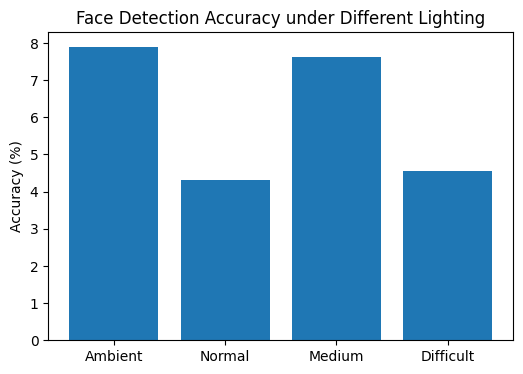

In [ ]:
labels = list(lighting.keys())

accuracy = []

for key in labels:

    accuracy.append(
        lighting_detect[key]/lighting[key]*100
    )

plt.figure(figsize=(6,4))

plt.bar(labels,accuracy)

plt.title("Face Detection Accuracy under Different Lighting")

plt.ylabel("Accuracy (%)")

plt.show()